# OCTO Mobile Google Play Review - Exploratory Data Analysis (EDA)

**Nama:** Alisha Rafimalia

**NRP:** 5026231202

**Kelas:** PBA A

**Notebook:** 1 - Data Scrapping & Initial EDA

Notebook ini berisi proses pengambilan data review aplikasi OCTO Mobile dari Google Play, pembersihan data awal, visualisasi eksploratif, dan ekspor dataset hasil scraping.

## Daftar Isi

1. Setup Environment
2. Data Scrapping Google Play Review
3. Data Cleaning dan Feature Engineering
4. Export Dataset
5. Visualisasi EDA

## 1. Setup Environment

Install library yang dibutuhkan untuk scraping, manipulasi data, dan visualisasi.

In [1]:
!pip -q install google-play-scraper pandas seaborn matplotlib

### Penjelasan Output
- Sel ini biasanya menampilkan proses instalasi package.
- Jika tidak ada error berwarna merah, artinya environment sudah siap untuk lanjut scraping dan analisis.

## 2. Data Scrapping Google Play Review

Pada tahap ini data review OCTO Mobile diambil bertahap menggunakan continuation token agar lebih stabil untuk data dalam jumlah besar.

In [2]:
from google_play_scraper import Sort, reviews
import pandas as pd

def scrape_reviews(app_id: str, total_count: int = 5000, batch_size: int = 200):
    """Scrape review Google Play secara bertahap dengan continuation token."""
    all_reviews = []
    token = None

    while len(all_reviews) < total_count:
        remaining = total_count - len(all_reviews)
        current_batch = min(batch_size, remaining)

        result, token = reviews(
            app_id,
            lang="id",
            country="id",
            sort=Sort.NEWEST,
            count=current_batch,
            continuation_token=token,
            filter_score_with=None,
        )

        if not result:
            break

        all_reviews.extend(result)

        # Jika token habis, berarti sudah tidak ada data lanjutan.
        if token is None:
            break

    return pd.DataFrame(all_reviews)

# Ambil data ulasan OCTO Mobile
df_octo = scrape_reviews(
    app_id="id.co.cimbniaga.mobile.android",
    total_count=5000,
    batch_size=200,
    )

print(f"Total review berhasil diambil: {len(df_octo)}")
df_octo.head()

Total review berhasil diambil: 5000


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,b5e135fc-94c4-4a35-bbfc-f8cc3a977367,erli shop,https://play-lh.googleusercontent.com/a/ACg8oc...,faforit banget. user friendly,5,0,NaN,2026-04-05 13:11:16,Terima kasih atas bintang lima dan review nya....,2026-04-05 13:15:19,NaN
1,61ea84b8-43b2-4883-ac0f-d55c99319646,Muhamad Rizki,https://play-lh.googleusercontent.com/a-/ALV-U...,aneh aplikasi sudah versi terbaru tapi tetep G...,3,0,NaN,2026-04-05 12:54:35,Mohon maaf atas ketidaknyamanan yang dialami. ...,2026-04-05 13:15:22,NaN
2,b81ce971-d1d9-4280-958f-39a79847ddb5,tia lestari dewi,https://play-lh.googleusercontent.com/a-/ALV-U...,give good transaction experience,5,0,3.1.85,2026-04-05 12:46:55,Thank you very much for the compliment! Keep u...,2026-04-05 13:14:55,3.1.85
3,88a4987c-ef87-4246-a5dc-d5be07fd2eb3,Rony Rihard,https://play-lh.googleusercontent.com/a-/ALV-U...,"CIMB memang virtual account ter ""the best"", cu...",5,0,3.1.85,2026-04-05 11:38:12,Terima kasih atas supportnya. Aplikasi OCTO se...,2026-04-05 11:45:41,3.1.85
4,b5298f85-2875-4668-a32d-2f2f4db451b4,Awaluddin M,https://play-lh.googleusercontent.com/a-/ALV-U...,mantap gratis admin,5,0,3.1.83,2026-04-05 10:21:01,Terima kasih atas bintang lima dan review nya....,2026-04-05 10:45:43,3.1.83


### Penjelasan Output
- Output `Total review berhasil diambil` menunjukkan jumlah data mentah yang berhasil di-scrape.
- Tabel `head()` menampilkan 5 baris awal untuk validasi struktur kolom seperti `content`, `score`, dan waktu review.
- Jika jumlah baris kecil dari target, biasanya karena batas data dari API pada waktu scraping.

## 3. Data Cleaning dan Feature Engineering

Pada bagian ini data dibersihkan, dipilih kolom penting, dibuat fitur tambahan, dan diberi label sentimen sederhana berbasis skor.

In [5]:
def prepare_clean_data(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Membersihkan data review dan menambahkan fitur turunan."""
    kolom_penting = [
        "reviewId", "userName", "score", "content", "at", "thumbsUpCount", "replyContent", "repliedAt"
    ]

    df_cleaned = df_raw[kolom_penting].copy()
    df_cleaned = df_cleaned.drop_duplicates(subset=["reviewId"])
    df_cleaned = df_cleaned[df_cleaned["content"].notna()]
    df_cleaned["content"] = df_cleaned["content"].astype(str).str.strip()
    df_cleaned = df_cleaned[df_cleaned["content"] != ""]

    df_cleaned["at"] = pd.to_datetime(df_cleaned["at"], errors="coerce")
    df_cleaned["repliedAt"] = pd.to_datetime(df_cleaned["repliedAt"], errors="coerce")

    df_cleaned["review_length"] = df_cleaned["content"].str.len()
    df_cleaned["month"] = df_cleaned["at"].dt.to_period("M").astype(str)

    def map_sentimen(score: int) -> str:
        if score >= 4:
            return "positif"
        if score == 3:
            return "netral"
        return "negatif"

    df_cleaned["sentimen_label"] = df_cleaned["score"].apply(map_sentimen)
    return df_cleaned

# Jalankan proses cleaning
df_clean = prepare_clean_data(df_octo)

print("Ukuran data bersih:", df_clean.shape)
print("Distribusi sentimen:")
print(df_clean["sentimen_label"].value_counts())
df_clean.head()

Ukuran data bersih: (5000, 11)
Distribusi sentimen:
sentimen_label
positif    3885
negatif     943
netral      172
Name: count, dtype: int64


,reviewId,userName,score,content,at,thumbsUpCount,replyContent,repliedAt,review_length,month,sentimen_label
0,b5e135fc-94c4-4a35-bbfc-f8cc3a977367,erli shop,5,faforit banget. user friendly,2026-04-05 13:11:16,0,Terima kasih atas bintang lima dan review nya....,2026-04-05 13:15:19,29,2026-04,positif
1,61ea84b8-43b2-4883-ac0f-d55c99319646,Muhamad Rizki,3,aneh aplikasi sudah versi terbaru tapi tetep G...,2026-04-05 12:54:35,0,Mohon maaf atas ketidaknyamanan yang dialami. ...,2026-04-05 13:15:22,151,2026-04,netral
2,b81ce971-d1d9-4280-958f-39a79847ddb5,tia lestari dewi,5,give good transaction experience,2026-04-05 12:46:55,0,Thank you very much for the compliment! Keep u...,2026-04-05 13:14:55,32,2026-04,positif
3,88a4987c-ef87-4246-a5dc-d5be07fd2eb3,Rony Rihard,5,"CIMB memang virtual account ter ""the best"", cu...",2026-04-05 11:38:12,0,Terima kasih atas supportnya. Aplikasi OCTO se...,2026-04-05 11:45:41,153,2026-04,positif
4,b5298f85-2875-4668-a32d-2f2f4db451b4,Awaluddin M,5,mantap gratis admin,2026-04-05 10:21:01,0,Terima kasih atas bintang lima dan review nya....,2026-04-05 10:45:43,19,2026-04,positif


### Penjelasan Output
- `Ukuran data bersih` menampilkan jumlah baris dan kolom setelah pembersihan data.
- `Distribusi sentimen` menunjukkan proporsi label positif, netral, dan negatif.
- Tabel `head()` mengonfirmasi bahwa kolom turunan seperti `review_length`, `month`, dan `sentimen_label` sudah terbentuk.

## 4. Export Dataset

Simpan data mentah dan data bersih ke format CSV agar bisa dipakai untuk tahap preprocessing/modeling berikutnya.

In [6]:
# Simpan data mentah dan data bersih
raw_path = "hasil_scraping_octo_raw.csv"
clean_path = "hasil_scraping_octo_clean.csv"

if "df_octo" not in globals():
    raise NameError("df_octo belum ada. Jalankan dulu bagian 2 (Data Scrapping).")

if "df_clean" not in globals():
    print("df_clean belum ada, sistem akan membuatnya otomatis dari df_octo...")

    if "prepare_clean_data" not in globals():
        def prepare_clean_data(df_raw: pd.DataFrame) -> pd.DataFrame:
            kolom_penting = [
                "reviewId", "userName", "score", "content", "at", "thumbsUpCount", "replyContent", "repliedAt"
            ]
            df_cleaned = df_raw[kolom_penting].copy()
            df_cleaned = df_cleaned.drop_duplicates(subset=["reviewId"])
            df_cleaned = df_cleaned[df_cleaned["content"].notna()]
            df_cleaned["content"] = df_cleaned["content"].astype(str).str.strip()
            df_cleaned = df_cleaned[df_cleaned["content"] != ""]
            df_cleaned["at"] = pd.to_datetime(df_cleaned["at"], errors="coerce")
            df_cleaned["repliedAt"] = pd.to_datetime(df_cleaned["repliedAt"], errors="coerce")
            df_cleaned["review_length"] = df_cleaned["content"].str.len()
            df_cleaned["month"] = df_cleaned["at"].dt.to_period("M").astype(str)
            def map_sentimen(score: int) -> str:
                if score >= 4:
                    return "positif"
                if score == 3:
                    return "netral"
                return "negatif"
            df_cleaned["sentimen_label"] = df_cleaned["score"].apply(map_sentimen)
            return df_cleaned

    df_clean = prepare_clean_data(df_octo)

df_octo.to_csv(raw_path, index=False)
df_clean.to_csv(clean_path, index=False)
print(f"File tersimpan: {raw_path}, {clean_path}")

# Download otomatis jika dijalankan di Google Colab
try:
    from google.colab import files
    files.download(raw_path)
    files.download(clean_path)
except ImportError:
    print("Bukan environment Colab, lewati proses download otomatis.")

File tersimpan: hasil_scraping_octo_raw.csv, hasil_scraping_octo_clean.csv
Bukan environment Colab, lewati proses download otomatis.


### Penjelasan Output
- Output ini memberi konfirmasi nama file CSV yang berhasil disimpan.
- Jika dijalankan di Colab, file akan otomatis terunduh.
- Jika dijalankan di lokal/VS Code, pesan `lewati proses download otomatis` adalah normal dan bukan error.

## 5. Visualisasi EDA

Visualisasi ini membantu melihat distribusi rating, tren review dari waktu ke waktu, dan karakteristik panjang teks review.

/var/folders/jy/25s3m3b54pgdyx0v91ylfww40000gn/T/ipykernel_51482/1943090218.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="score", palette="Blues")


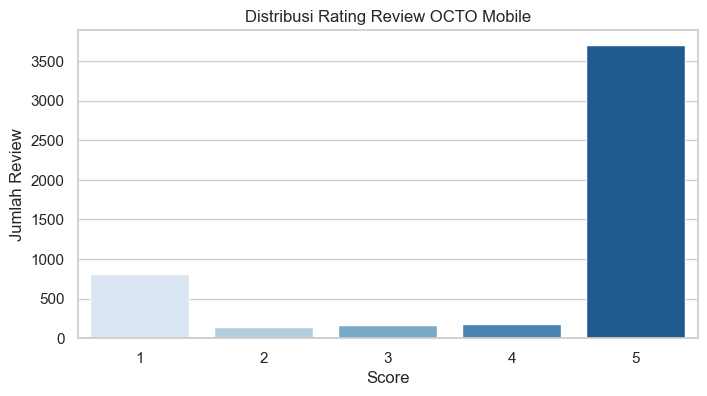

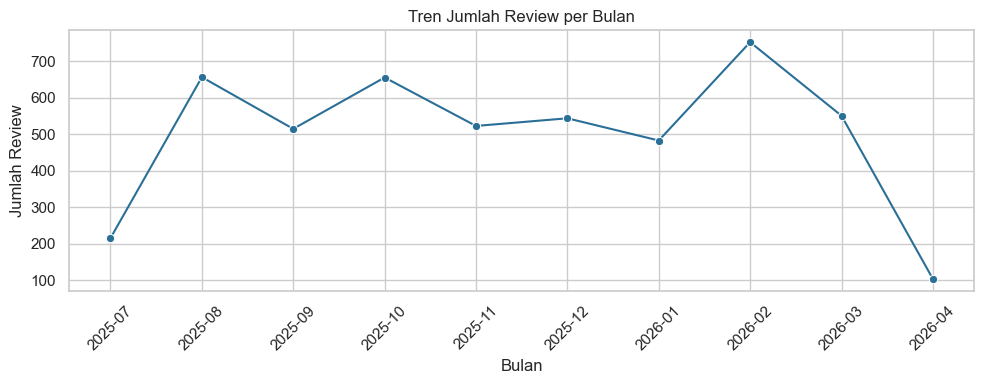

/var/folders/jy/25s3m3b54pgdyx0v91ylfww40000gn/T/ipykernel_51482/1943090218.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="score", y="review_length", palette="crest")


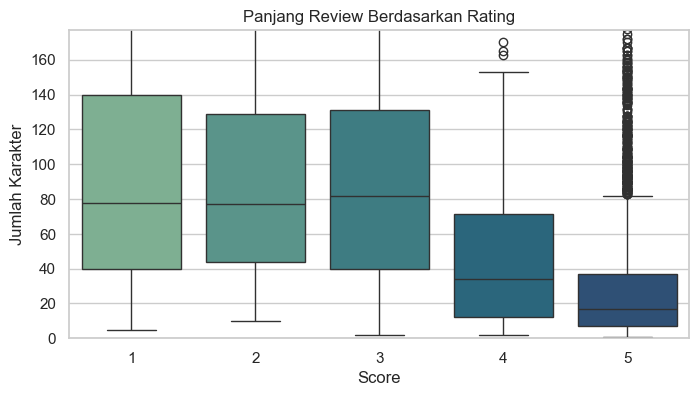

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

if "df_octo" not in globals():
    raise NameError("df_octo belum ada. Jalankan dulu bagian 2 (Data Scrapping).")

if "df_clean" not in globals():
    print("df_clean belum ada, sistem akan membuatnya otomatis dari df_octo...")

    if "prepare_clean_data" not in globals():
        def prepare_clean_data(df_raw: pd.DataFrame) -> pd.DataFrame:
            kolom_penting = [
                "reviewId", "userName", "score", "content", "at", "thumbsUpCount", "replyContent", "repliedAt"
            ]
            df_cleaned = df_raw[kolom_penting].copy()
            df_cleaned = df_cleaned.drop_duplicates(subset=["reviewId"])
            df_cleaned = df_cleaned[df_cleaned["content"].notna()]
            df_cleaned["content"] = df_cleaned["content"].astype(str).str.strip()
            df_cleaned = df_cleaned[df_cleaned["content"] != ""]
            df_cleaned["at"] = pd.to_datetime(df_cleaned["at"], errors="coerce")
            df_cleaned["repliedAt"] = pd.to_datetime(df_cleaned["repliedAt"], errors="coerce")
            df_cleaned["review_length"] = df_cleaned["content"].str.len()
            df_cleaned["month"] = df_cleaned["at"].dt.to_period("M").astype(str)
            def map_sentimen(score: int) -> str:
                if score >= 4:
                    return "positif"
                if score == 3:
                    return "netral"
                return "negatif"
            df_cleaned["sentimen_label"] = df_cleaned["score"].apply(map_sentimen)
            return df_cleaned

    df_clean = prepare_clean_data(df_octo)

sns.set_theme(style="whitegrid")

# 1) Distribusi rating
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x="score", palette="Blues")
plt.title("Distribusi Rating Review OCTO Mobile")
plt.xlabel("Score")
plt.ylabel("Jumlah Review")
plt.show()

# 2) Tren jumlah review per bulan
review_per_bulan = df_clean.groupby("month").size().reset_index(name="jumlah_review")
review_per_bulan = review_per_bulan.sort_values("month")

plt.figure(figsize=(10, 4))
sns.lineplot(data=review_per_bulan, x="month", y="jumlah_review", marker="o", color="#2A6F97")
plt.title("Tren Jumlah Review per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Review")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3) Rata-rata panjang review per rating
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x="score", y="review_length", palette="crest")
plt.title("Panjang Review Berdasarkan Rating")
plt.xlabel("Score")
plt.ylabel("Jumlah Karakter")
plt.ylim(0, df_clean["review_length"].quantile(0.95))
plt.show()

### Penjelasan Output
- Grafik distribusi rating menunjukkan dominasi skor tertentu (misalnya mayoritas 4-5).
- Grafik tren bulanan menunjukkan pola naik-turun volume review dari waktu ke waktu.
- Boxplot panjang review membantu membaca apakah review bernilai rendah cenderung lebih panjang atau tidak.
- Ketiga grafik ini menjadi dasar insight sebelum masuk ke tahap NLP lanjutan.